# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Instalasi library mlibs

In [24]:
!pip install mllibs
!pip install geoplot

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [25]:
#Type your code here
import numpy as np
from numpy.linalg import pinv,inv
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns;sns.set(style='whitegrid')
%matplotlib inline

import geoplot as gplt
import geoplot.crs as gcrs
import mapclassify as mc

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, RegressorMixin,ClassifierMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
pi = 4.0*np.arctan(1.0)

color1 = 'darkviolet'
color2 = 'indigo'

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [26]:
#Type your code here
df = pd.read_csv('./housing.csv')

In [27]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [29]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Terdapat data yang memiliki nilai null

In [30]:
df.duplicated().sum()

np.int64(0)

Tidak ada data dengan nilai duplikat

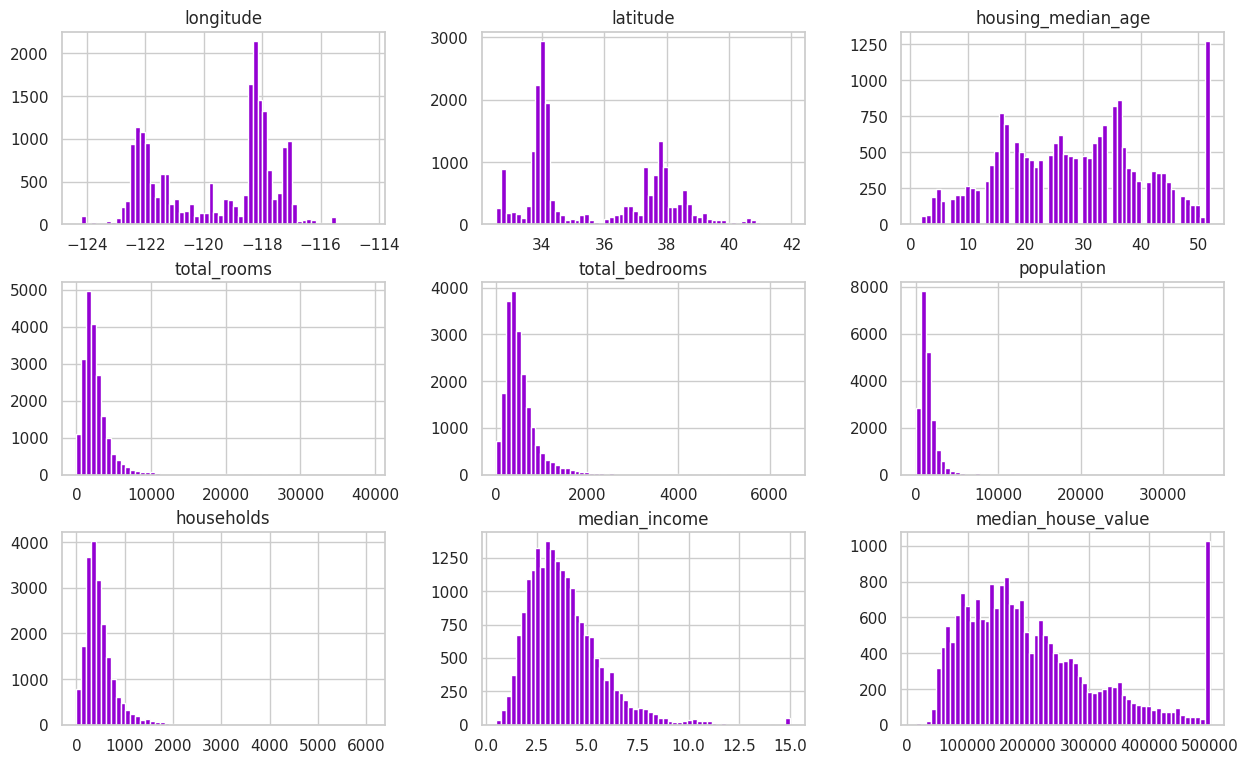

In [31]:
#Type your code here
df.hist(bins=60, figsize=(15,9),color='darkviolet');plt.show()

**Hasil**

Berdasarkan hasil dari grafik diatas ditemukan beberapa distribusi data yang terindikasi sebagai outlier



1.   *house_median_age*: Terindikasi memiliki outlier karena data memiliki 1 ketinggian yang terlalu berbeda pada rentang umur hunian 50 tahun
2.   *median_house_value*: Ketinggian yang menurun semakin tinggi value x yang dimiliki, namun dengan rentang x tertinggi (50000) justru memiliki ketinggian tertinggi dibanding titik tertinggi dari distribusi (800)


Kolom lain memiliki distribusi data yng cukup merata



In [ ]:
LE = LabelEncoder()
df['ocean_proximity'] = LE.fit_transform(df['ocean_proximity'])

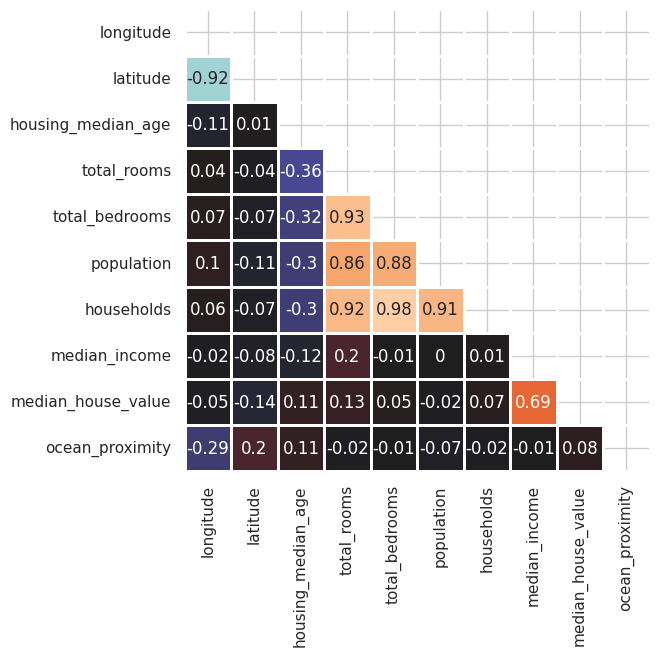

In [33]:
def corrMat(df):
  corr_mat = df.corr().round(2)
  f, ax = plt.subplots(figsize=(6,6))
  mask = np.zeros_like(corr_mat,dtype=np.bool)
  mask[np.triu_indices_from(mask)] = True
  sns.heatmap(corr_mat,mask=mask,vmin=-1,vmax=1,center=0,
              square=False,lw=2,annot=True,cbar=False);plt.show()
corrMat(df)

Berdasarkan grafik diatas, dapat disimpulkan hal berikut:

1. ocean_proximity: hanya memiliki koreasi yang ringan antar kolom, namun memiliki 1 korelasi yang cukup sebanyak -0.29 pada longitude
2. median_income: memiliki korelasi yang rendah antar kolom dengan range namun korelasi cukup tinggi pada median_house_value

Berdasarkan pengamatn dapa disimpulkan, kalau data memiliki distribusi yang lebih acak

In [34]:
def snsPairGrid(df):

    ''' Plots a Seaborn Pairgrid w/ KDE & scatter plot of df features'''
    g = sns.PairGrid(df,diag_sharey=False)
    g.fig.set_size_inches(14,13)
    g.map_diag(sns.kdeplot, lw=2) # draw kde approximation on the diagonal
    g.map_lower(sns.scatterplot,s=15,edgecolor="k",linewidth=1,alpha=0.4) # scattered plot on lower half
    g.map_lower(sns.kdeplot,cmap='plasma',n_levels=10) # kde approximation on lower half
    plt.tight_layout()

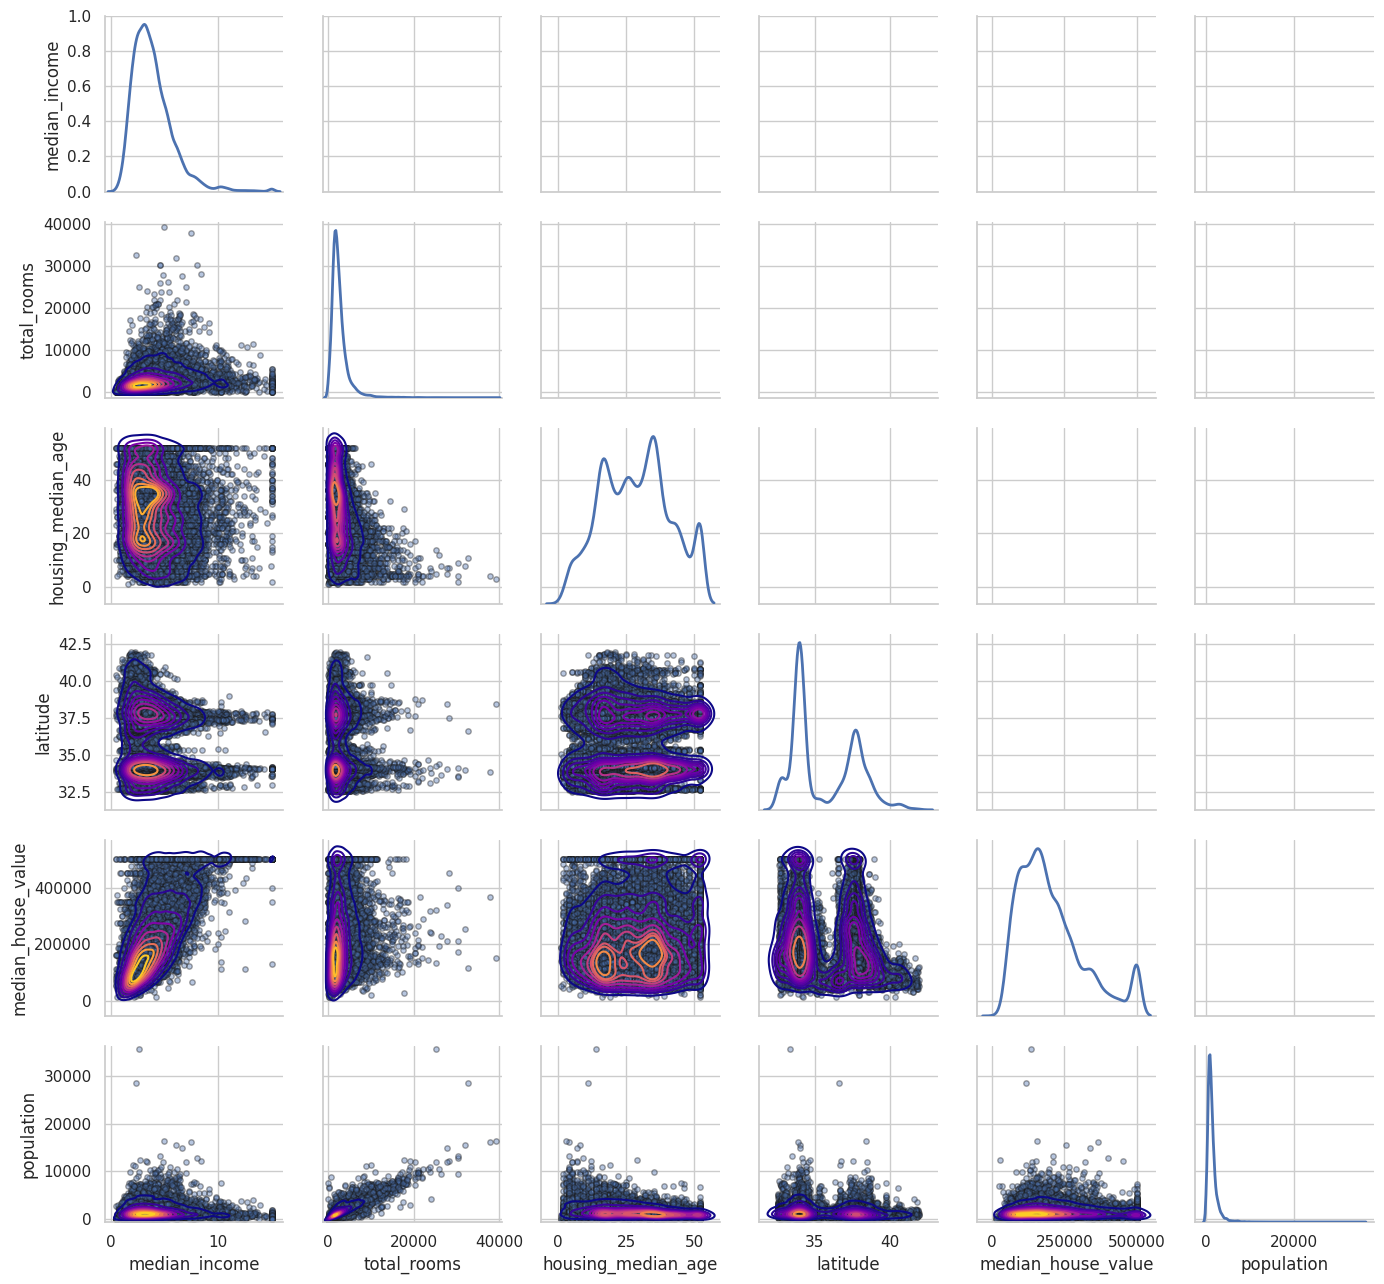

In [35]:
# Seaborn get a little slow, let's plot some interesting features
tlist = ['median_income','total_rooms','housing_median_age','latitude','median_house_value','population']
snsPairGrid(df[tlist])

Berdasarkan grafik diatas, berikut beberapa korelasi unik antar kolom.

1. Hubungan antara *median_house_value* dan *median_income* tampak cukup linier, dengan sedikit penyimpangan yang normal terhadap garis linier tersebut
2. Dalam hubungan antara *median_house_age* dan *median_house_value*, tampaknya data tersebar secara merata ke segala arah. Hubungannya sangat nonlinier, tersebar di mana-mana, dengan data di hampir seluruh bagian grafik.
3. *median_house_value* & *total_rooms*, *population* tampaknya merupakan fitur yang cukup kompleks untuk dimodelkan. KDE menunjukkan bahwa data sangat terkonsentrasi pada nilai-nilai rendah untuk kedua fitur tersebut, dengan sebagian kecil pada nilai-nilai yang lebih besar, serta banyak data di luar kluster utama yang dapat diklasifikasikan sebagai outlier.
4. Tinggi nya nilai pada grafik untuk beberapa kolom, mempertimbangkan untuk menggunakan scaler



In [36]:
def plotTwo(df,lst):

    # load california from module, common for all plots
    cali = gpd.read_file(gplt.datasets.get_path('california_congressional_districts'))
    cali = cali.assign(area=cali.geometry.area)

    # Create a geopandas geometry feature; input dataframe should contain .longtitude, .latitude
    gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.longitude,df.latitude))
    proj=gcrs.AlbersEqualArea(central_latitude=37.16611, central_longitude=-119.44944) # related to view

    ii=-1
    fig,ax = plt.subplots(1,2,figsize=(21,6),subplot_kw={'projection': proj})
    for i in lst:

        ii+=1
        tgdf = gdf.sort_values(by=i,ascending=True)
        gplt.polyplot(cali,projection=proj,ax=ax[ii]) # the module already has california
        gplt.pointplot(tgdf,ax=ax[ii],hue=i,cmap='plasma',legend=True,alpha=1.0,s=3) #
        ax[ii].set_title(i)

    plt.tight_layout()
    plt.subplots_adjust(wspace=-0.5)

/tmp/ipykernel_475/1958706767.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cali = cali.assign(area=cali.geometry.area)
/tmp/ipykernel_475/1958706767.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cali = cali.assign(area=cali.geometry.area)


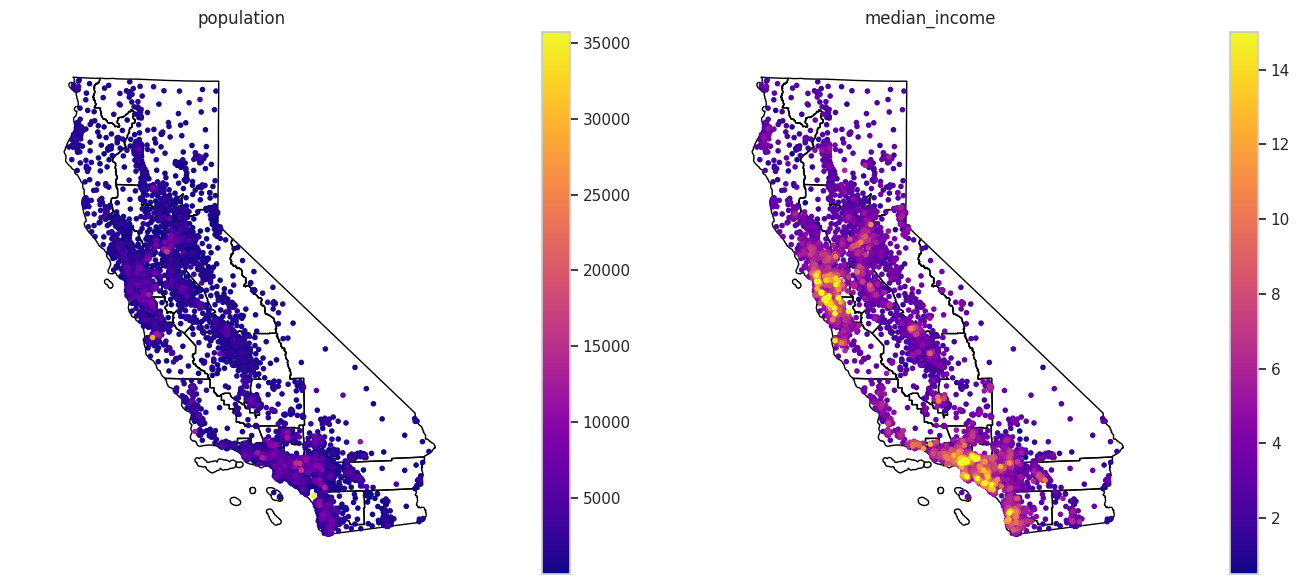

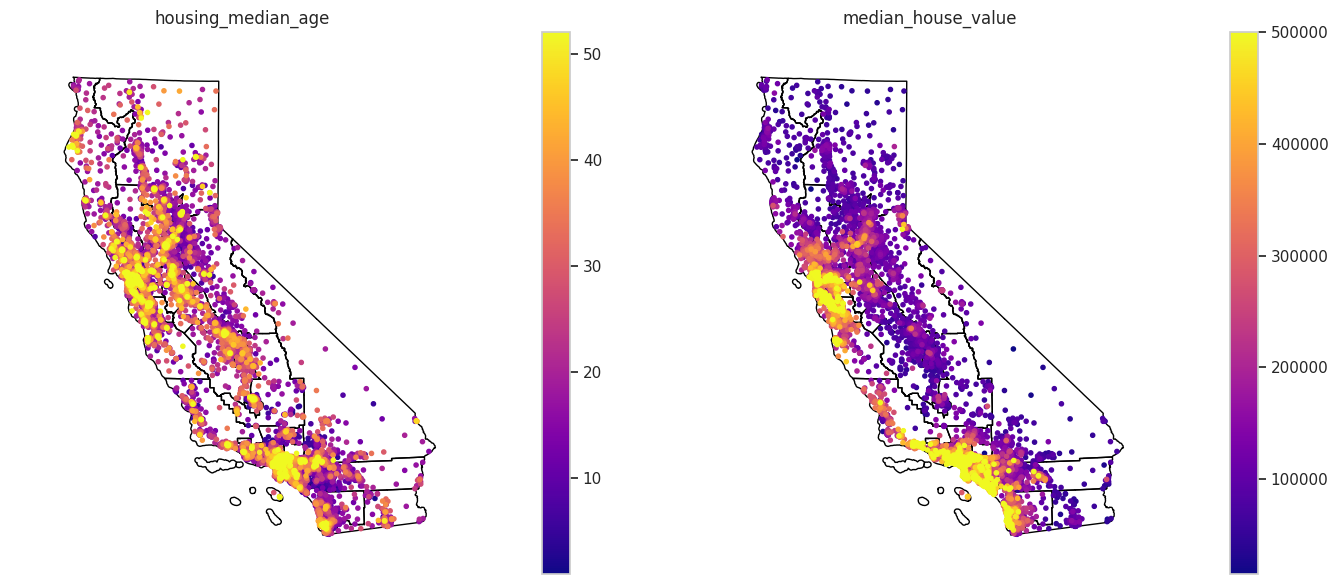

In [38]:
# Call function that plots two geopandas plots
plotTwo(df,['population','median_income'])
plotTwo(df,['housing_median_age','median_house_value'])



1.   Untuk variabel target kita, median_house_value, hanya dengan melihat grafik-grafik ini, kita dapat langsung melihat beberapa pola; Median_house_income menunjukkan hubungan yang jelas; umumnya nilainya meningkat seiring mendekat ke dua kluster utama, sehingga kedua fitur ini memiliki korelasi yang tinggi dan mungkin tinggi.

2.  Housing_median_age untuk banyak wilayah juga sangat berkorelasi dengan variabel target, tetapi di banyak wilayah lainnya tidak (sedikit lebih ke pedalaman), sehingga tidak begitu jelas. Hubungannya mungkin hanya nonlinier. Namun kita dapat melihat dua kluster utama dari grafik tersebut, yang menunjukkan beberapa aspek linearitas.

3. Populasi sedikit lebih rumit; ada korelasi tertentu, meskipun terdapat beberapa outlier (bahkan tidak terlihat pada histogram univariat) yang membuat hubungan tersebut sulit dilihat karena nilai-nilai lebih terkonsentrasi di kelompok < 10k.




# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [40]:
# Karena terdapat data yang memiliki nilai null, dapat melakukan drop baris (karena data yang hilang tidak lebih dari 10%)
df.dropna(inplace=True)

In [41]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
# Karena terdapat kolom yang outlier, maka ganti value dengan nilai tertinggi dalam kolom

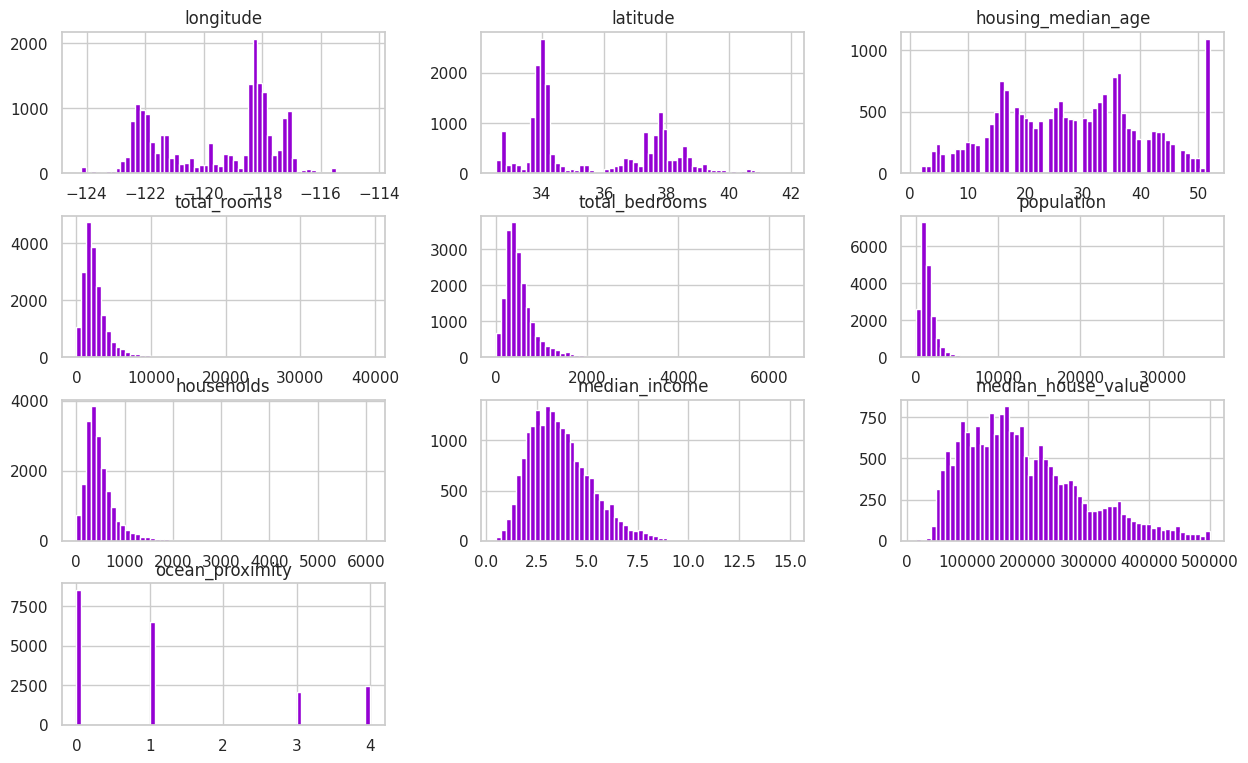

In [42]:
maxval2 = df['median_house_value'].max() # get the maximum value
df_updated = df[df['median_house_value'] != maxval2]
df_updated.hist(bins=60, figsize=(15,9),color=color1);plt.show()

1. Pada kolom *housing_median_age*, tidak dilakukan penghapusan data pada outlier. Karena data tersebut tidak memberikan informasi yang signifikan dan memiliki dampak stagnan.
2. Kolom target, sangat diragukan bahwa lonjakan nilai yang menyimpang itu bukanlah penjumlahan yang telah ditentukan secara tegas dari semua kasus yang nilainya melebihi nilai median_house_value maksimum. Jadi dilakukan penghapusan outlier ini

In [43]:
df_updated.to_csv('housing_clean.csv')